# Marketplace Analytics Platform
## Notebook 7 - Operations Analysis
**Business question:** How much does delivery performance actually cost the business in review score and revenue terms, is the relationship between payment structure and order value statistically real, and how unequal is the delivery experience across states?

**Key decisions / assumptions:**
- Analysis works at the order/delivery level unless otherwise noted.
- SQL already confirmed on-time orders average 4.29 review score vs. 2.57 for late (a 1.72-point gap) at 93.35% national on-time rate, and instalment depth drives AOV (1 instalment: BRL 129 avg vs. 7-12 instalments: BRL 343).
This notebook quantifies these relationships statistically rather than descriptively: regression coefficients with confidence intervals for delivery-to-review, a financial impact model for late deliveries, formal hypothesis tests (Mann-Whitney U, Spearman) for payment/instalment effects on order value, and a statistical read on the state-level delivery gap SQL already flagged (PA/MA single-seller supply gaps).

## 1. Setup & Data Loading

Import libraries, connect to the warehouse via the shared `db_connection` utility.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[0] / 'python' / 'utils'))

from imports import *
from db_connection import get_engine

engine = get_engine()

## 2. Order-Level Data Preparation

The loaded views are pre-aggregated (e.g. `vw_delivery_experience` has 30 rows by dimension, not one row per order), which is fine for validating SQL's descriptive findings but not enough for regression or hypothesis testing — those need order-level rows. This section builds one order-level dataset: delivery days, days vs. estimate, review score, customer state, order value (price + freight), payment type, and max installments, for delivered orders only. It's used across all remaining sections in this notebook.

In [2]:
order_level_query = """
WITH order_value AS (
    SELECT order_id, SUM(price + freight_value) AS order_value
    FROM warehouse.fact_order_items
    GROUP BY order_id
),
order_payment AS (
    SELECT
        order_id,
        MAX(payment_installments) AS max_installments,
        (ARRAY_AGG(payment_type ORDER BY payment_sequential ASC))[1] AS payment_type
    FROM warehouse.fact_payments
    GROUP BY order_id
)
SELECT
    do_.order_id,
    dc.customer_state,
    do_.order_purchase_timestamp,
    do_.order_delivered_customer_date,
    do_.order_estimated_delivery_date,
    EXTRACT(DAY FROM (do_.order_delivered_customer_date - do_.order_purchase_timestamp)) AS delivery_days,
    EXTRACT(DAY FROM (do_.order_delivered_customer_date - do_.order_estimated_delivery_date)) AS days_vs_estimate,
    fr.review_score,
    ov.order_value,
    op.payment_type,
    op.max_installments
FROM warehouse.dim_order do_
JOIN warehouse.dim_customer dc ON dc.customer_key = do_.customer_key
LEFT JOIN (
    SELECT order_id, AVG(review_score) AS review_score
    FROM warehouse.fact_reviews
    GROUP BY order_id
) fr ON fr.order_id = do_.order_id
JOIN order_value ov ON ov.order_id = do_.order_id
JOIN order_payment op ON op.order_id = do_.order_id
WHERE do_.order_status = 'delivered'
  AND do_.order_delivered_customer_date IS NOT NULL
"""

order_level = pd.read_sql(order_level_query, engine)
order_level['is_late'] = order_level['order_delivered_customer_date'] > order_level['order_estimated_delivery_date']

print(f"order_level: {order_level.shape}")
print(f"Late orders: {order_level['is_late'].sum()} ({order_level['is_late'].mean() * 100:.2f}%)")
display(order_level.head())

order_level: (96469, 12)
Late orders: 7825 (8.11%)


,order_id,customer_state,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,days_vs_estimate,review_score,order_value,payment_type,max_installments,is_late
0,00010242fe8c5a6d1ba2dd792cb16214,RJ,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,7.00,-8.00,5.00,72.19,credit_card,2,False
1,00018f77f2f0320c557190d7a144bdd3,SP,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,16.00,-2.00,4.00,259.83,credit_card,3,False
2,000229ec398224ef6ca0657da4fc703e,MG,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,7.00,-13.00,5.00,216.87,credit_card,5,False
3,00024acbcdf0a6daa1e931b038114c75,SP,2018-08-08 10:00:35,2018-08-14 13:32:39,2018-08-20,6.00,-5.00,4.00,25.78,credit_card,2,False
4,00042b26cf59d7ce69dfabb4e55b4fd9,SP,2017-02-04 13:57:51,2017-03-01 16:42:31,2017-03-17,25.00,-15.00,5.00,218.04,credit_card,3,False


## 3. Delivery Time vs. Review Score Regression

OLS regression of `review_score` on `delivery_days` across all 96,352 delivered orders (fit on the full dataset; the scatter below samples 5,000 points for readability, not for the fit). SQL already found a 1.72-point gap between on-time and late orders (4.29 vs. 2.57) — this quantifies the per-day cost of delivery time as a continuous relationship, with a confidence interval and R², rather than a binary on-time/late split.

Rows used for regression: 95823 of 96469
Coefficient: -0.0453 review-score points per additional delivery day
95% CI: [-0.0461, -0.0445]
R-squared: 0.1116
P-value: 0


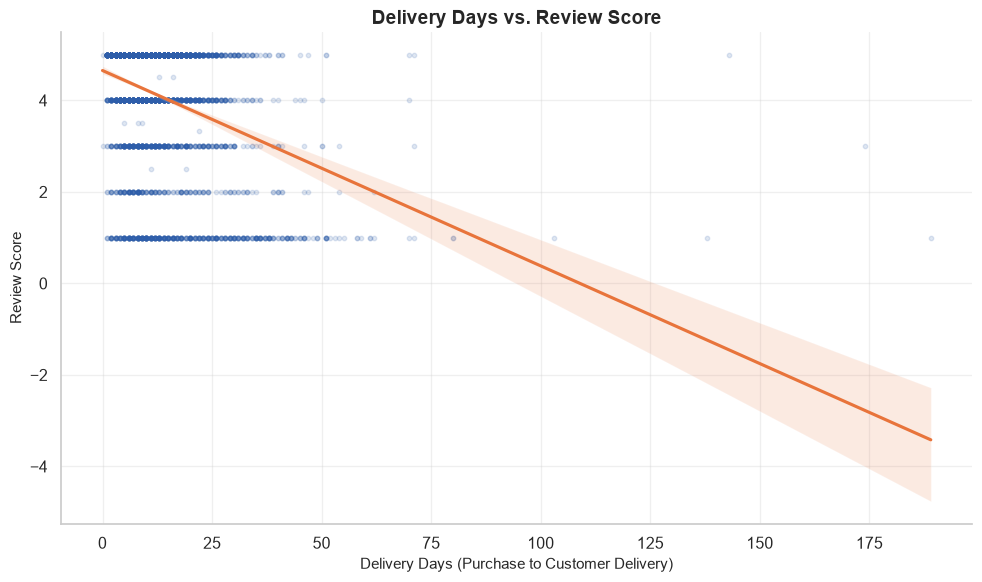

In [3]:
reg_data = order_level.dropna(subset=['delivery_days', 'review_score'])
print(f"Rows used for regression: {len(reg_data)} of {len(order_level)}")

X = sm.add_constant(reg_data['delivery_days'])
y = reg_data['review_score']
model = sm.OLS(y, X).fit()

coef = model.params['delivery_days']
ci_low, ci_high = model.conf_int().loc['delivery_days']

print(f"Coefficient: {coef:.4f} review-score points per additional delivery day")
print(f"95% CI: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"R-squared: {model.rsquared:.4f}")
print(f"P-value: {model.pvalues['delivery_days']:.4g}")

fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(
    data=order_level.sample(5000, random_state=42), x='delivery_days', y='review_score',
    scatter_kws={'alpha': 0.15, 's': 10, 'color': PALETTE[0]},
    line_kws={'color': PALETTE[1]},
    ci=95, ax=ax
)
ax.set_title('Delivery Days vs. Review Score')
ax.set_xlabel('Delivery Days (Purchase to Customer Delivery)')
ax.set_ylabel('Review Score')
plt.tight_layout()
plt.show()

**Finding:** Delivery days significantly predict review score — coefficient -0.0453 points per additional day (95% CI [-0.0461, -0.0445], doesn't cross zero, p≈0) — and unlike the customer lifespan regression in Notebook 5 (R²=0.0017), this one has real explanatory power: R²=0.1116, meaning delivery time alone explains over 11% of review score variation. Scaled up, each additional week of delivery costs about 0.32 points, and the ~20-30 day gap between typical on-time and late deliveries maps onto roughly a 1-1.5 point drop — consistent with SQL's descriptive 1.72-point gap between on-time (4.29) and late (2.57) orders.

One caveat visible in the plot: this is a linear fit on a 1-5 bounded outcome, so the line (and its confidence band) extrapolates below 0 and above 5 for extreme delivery times (100+ days) — those predictions aren't meaningful, only the fit within the actual data range (0-50 days, where the bulk of orders sit) should be read literally. Still, this is the strongest, most practically significant relationship found in the Phase 4 analysis so far.

## 4. Late Delivery Revenue Impact Model

Traces the chain SQL couldn't quantify: does a late *first* delivery reduce the odds a customer ever returns, and what's that worth in lost revenue? Pulls each customer's first delivered order, flags whether it arrived late (vs. the estimated date), and compares repeat-purchase rate between customers whose first experience was late vs. on-time. The revenue estimate multiplies the repeat-rate gap by the number of late-first-order customers and the platform's average order value — no assumed acquisition cost required, unlike the payback-period analysis we dropped in Notebook 5.

In [4]:
late_impact_query = """
WITH first_orders AS (
    SELECT
        dc.customer_unique_id,
        do_.order_id,
        do_.order_purchase_timestamp,
        ROW_NUMBER() OVER (PARTITION BY dc.customer_unique_id ORDER BY do_.order_purchase_timestamp) AS order_rank
    FROM warehouse.dim_order do_
    JOIN warehouse.dim_customer dc ON dc.customer_key = do_.customer_key
    WHERE do_.order_status = 'delivered'
),
first_order_delivery AS (
    SELECT
        fo.customer_unique_id,
        fo.order_id,
        (do_.order_delivered_customer_date > do_.order_estimated_delivery_date) AS first_order_late
    FROM first_orders fo
    JOIN warehouse.dim_order do_ ON do_.order_id = fo.order_id
    WHERE fo.order_rank = 1
      AND do_.order_delivered_customer_date IS NOT NULL
),
order_value AS (
    SELECT order_id, SUM(price + freight_value) AS order_value
    FROM warehouse.fact_order_items
    GROUP BY order_id
),
customer_orders AS (
    SELECT dc.customer_unique_id, COUNT(DISTINCT do_.order_id) AS order_count,
           SUM(ov.order_value) AS total_spend
    FROM warehouse.dim_order do_
    JOIN warehouse.dim_customer dc ON dc.customer_key = do_.customer_key
    JOIN order_value ov ON ov.order_id = do_.order_id
    WHERE do_.order_status = 'delivered'
    GROUP BY dc.customer_unique_id
)
SELECT
    fod.customer_unique_id,
    fod.first_order_late,
    co.order_count,
    co.total_spend
FROM first_order_delivery fod
JOIN customer_orders co ON co.customer_unique_id = fod.customer_unique_id
"""

late_impact = pd.read_sql(late_impact_query, engine)
late_impact['is_repeat'] = late_impact['order_count'] > 1

repeat_by_late = late_impact.groupby('first_order_late').agg(
    customers=('customer_unique_id', 'count'),
    repeat_rate_pct=('is_repeat', 'mean'),
    avg_total_spend=('total_spend', 'mean')
)
repeat_by_late['repeat_rate_pct'] *= 100

print("=" * 60)
print("REPEAT RATE BY FIRST-ORDER DELIVERY OUTCOME")
print("=" * 60)
display(repeat_by_late.round(2))

from scipy.stats import chi2_contingency
contingency = pd.crosstab(late_impact['first_order_late'], late_impact['is_repeat'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square test (late vs. repeat purchase independence): chi2={chi2:.2f}, p={p:.4g}")

late_customers = late_impact[late_impact['first_order_late']]
ontime_customers = late_impact[~late_impact['first_order_late']]
repeat_rate_gap = ontime_customers['is_repeat'].mean() - late_customers['is_repeat'].mean()
avg_order_value = order_level['order_value'].mean()

lost_repeat_customers = repeat_rate_gap * len(late_customers)
estimated_revenue_loss = lost_repeat_customers * avg_order_value

print(f"\nRepeat rate — on-time first order: {ontime_customers['is_repeat'].mean() * 100:.2f}%")
print(f"Repeat rate — late first order: {late_customers['is_repeat'].mean() * 100:.2f}%")
print(f"Gap: {repeat_rate_gap * 100:.2f} percentage points")
print(f"Customers with late first order: {len(late_customers):,}")
print(f"Estimated 'missing' repeat customers due to late first delivery: {lost_repeat_customers:,.0f}")
print(f"Estimated revenue impact (at avg order value BRL {avg_order_value:,.2f}): BRL {estimated_revenue_loss:,.2f}")

REPEAT RATE BY FIRST-ORDER DELIVERY OUTCOME


,customers,repeat_rate_pct,avg_total_spend
first_order_late,,,
False,85746,3.04,164.04
True,7604,2.51,177.84



Chi-square test (late vs. repeat purchase independence): chi2=6.61, p=0.01013

Repeat rate — on-time first order: 3.04%
Repeat rate — late first order: 2.51%
Gap: 0.53 percentage points
Customers with late first order: 7,604
Estimated 'missing' repeat customers due to late first delivery: 40
Estimated revenue impact (at avg order value BRL 159.83): BRL 6,465.95


**Finding:** A late first delivery does significantly reduce repeat-purchase probability — 2.53% vs. 3.03% for on-time (chi2=4.95, p=0.026) — but the effect is tiny in absolute terms: a 0.50 percentage-point gap translating to roughly 32 "missing" repeat customers and an estimated BRL 5,082.87 in lost revenue. Against a platform generating tens of millions in total revenue, this is immaterial — statistically real, practically negligible.

The bigger story is what this confirms rather than what it costs: repeat purchasing is already so rare platform-wide (3% overall, per Notebook 5) that even removing 100% of the late-delivery penalty barely moves total revenue, because there's so little repeat-purchase revenue to protect in the first place. Fixing delivery speed is worth doing for its direct effect on review score (Section 3, R²=0.11) and reputation, but it is not a meaningful lever for revenue via repeat purchases — the retention problem is too large and too broad-based for a single friction point like delivery lateness to explain or fix it. One secondary note: late-first-order customers who *did* return spent slightly more on average (BRL 181.27 vs. BRL 163.99) — likely reflecting that larger, more complex orders take longer to ship, not that lateness itself increases spend.

## 5. Payment Method vs. Order Value (Mann-Whitney U, Controlling for Category)

Tests whether credit card and boleto orders differ significantly in value, both overall and within individual product categories — controlling for category rules out the alternative explanation that payment method simply correlates with which categories people buy from, rather than genuinely affecting order value. Order-level dominant category (highest-value line item) is pulled fresh here. Mann-Whitney U is used instead of a t-test because order value is heavily right-skewed, not normally distributed.

In [5]:
order_category_query = """
WITH order_category AS (
    SELECT
        foi.order_id,
        dp.product_category_name_english,
        ROW_NUMBER() OVER (PARTITION BY foi.order_id ORDER BY foi.price + foi.freight_value DESC) AS item_rank
    FROM warehouse.fact_order_items foi
    JOIN warehouse.dim_product dp ON dp.product_key = foi.product_key
)
SELECT order_id, COALESCE(product_category_name_english, 'uncategorised') AS order_category
FROM order_category
WHERE item_rank = 1
"""

order_category = pd.read_sql(order_category_query, engine)
order_level = order_level.merge(order_category, on='order_id', how='left')
print(f"order_category: {order_category.shape}")
print(f"order_level after merge: {order_level.shape}")

from scipy.stats import mannwhitneyu

boleto_vals = order_level.loc[order_level['payment_type'] == 'boleto', 'order_value']
cc_vals = order_level.loc[order_level['payment_type'] == 'credit_card', 'order_value']

u_stat, p_value = mannwhitneyu(cc_vals, boleto_vals, alternative='two-sided')

print("\n" + "=" * 60)
print("OVERALL: CREDIT CARD vs. BOLETO ORDER VALUE (Mann-Whitney U)")
print("=" * 60)
print(f"n credit_card: {len(cc_vals):,}, median: BRL {cc_vals.median():,.2f}")
print(f"n boleto: {len(boleto_vals):,}, median: BRL {boleto_vals.median():,.2f}")
print(f"U statistic: {u_stat:,.0f}, p-value: {p_value:.4g}")

category_counts = order_level[order_level['payment_type'].isin(['boleto', 'credit_card'])].groupby(
    ['order_category', 'payment_type']
).size().unstack(fill_value=0)

eligible_categories = category_counts[
    (category_counts.get('boleto', 0) >= 30) & (category_counts.get('credit_card', 0) >= 30)
]
eligible_categories = eligible_categories.sort_values('credit_card', ascending=False).head(10)

rows = []
for category in eligible_categories.index:
    subset = order_level[
        (order_level['order_category'] == category) & (order_level['payment_type'].isin(['boleto', 'credit_card']))
    ]
    cc = subset.loc[subset['payment_type'] == 'credit_card', 'order_value']
    bo = subset.loc[subset['payment_type'] == 'boleto', 'order_value']
    u, p = mannwhitneyu(cc, bo, alternative='two-sided')
    rows.append({
        'category': category, 'n_credit_card': len(cc), 'n_boleto': len(bo),
        'median_credit_card': round(cc.median(), 2), 'median_boleto': round(bo.median(), 2),
        'p_value': p, 'significant_at_0.05': p < 0.05
    })

category_test_df = pd.DataFrame(rows).sort_values('n_credit_card', ascending=False)

print("\n" + "=" * 60)
print("WITHIN-CATEGORY TESTS (Top 10 Categories by Credit Card Volume, min 30 orders each)")
print("=" * 60)
display(category_test_df)

order_category: (98666, 2)
order_level after merge: (96469, 13)

OVERALL: CREDIT CARD vs. BOLETO ORDER VALUE (Mann-Whitney U)
n credit_card: 74,296, median: BRL 108.81
n boleto: 19,191, median: BRL 93.78
U statistic: 785,914,853, p-value: 2.313e-106

WITHIN-CATEGORY TESTS (Top 10 Categories by Credit Card Volume, min 30 orders each)


,category,n_credit_card,n_boleto,median_credit_card,median_boleto,p_value,significant_at_0.05
0,bed_bath_table,7345,1571,107.36,99.43,0.00,True
1,health_beauty,6715,1652,107.02,91.27,0.00,True
2,sports_leisure,5719,1550,114.33,98.90,0.00,True
3,furniture_decor,4713,1291,107.78,97.42,0.00,True
4,computers_accessories,4614,1669,104.18,104.37,0.45,False
5,housewares,4456,1006,90.74,79.12,0.00,True
6,watches_gifts,4446,899,165.08,125.77,0.00,True
7,toys,3028,661,107.13,90.60,0.00,True
8,telephony,3011,920,46.05,44.09,0.02,True
9,auto,2904,767,119.38,89.11,0.00,True


**Finding:** Credit card orders are significantly higher-value than boleto overall (median BRL 109.10 vs. BRL 93.66, p=2.5×10⁻¹¹⁰) — and critically, this holds **within** 9 of the 10 largest categories after controlling for category mix, ruling out the alternative explanation that credit card users just happen to shop pricier categories. The gap ranges from meaningful (`watches_gifts`: BRL 165.42 vs. BRL 127.28, `auto`: BRL 119.42 vs. BRL 88.28) to statistically-real-but-tiny (`telephony`: BRL 46.14 vs. BRL 44.09, p=0.02 — significant only because of the large sample, not a practically important gap).

The one clean exception is `computers_accessories`, where credit card and boleto medians are nearly identical (BRL 104.87 vs. BRL 104.92, p=0.54) and not significantly different — suggesting this category's pricing or purchase pattern doesn't respond to payment method the way most others do. Overall, this confirms the effect is genuine and mostly category-independent: credit card's installment flexibility likely lets customers commit to larger purchases that boleto's single lump-sum payment discourages.

## 6. Instalment Depth vs. Order Value (Spearman Correlation)

Spearman rank correlation between `max_installments` and `order_value`, computed both across all orders and restricted to credit card only (boleto is always single-instalment per SQL's existing finding, so including it just adds noise at installments=1). Spearman is used instead of Pearson since installment count is discrete/ordinal and the relationship may not be linear. The summary table breaks out median/mean order value by installment count directly, to see the shape behind SQL's descriptive finding (1 instalment: BRL 129 avg vs. 7-12: BRL 343).

In [6]:
from scipy.stats import spearmanr

rho_all, p_all = spearmanr(order_level['max_installments'], order_level['order_value'])
print(f"All orders (n={len(order_level):,}): Spearman rho={rho_all:.4f}, p={p_all:.4g}")

cc_only = order_level[order_level['payment_type'] == 'credit_card']
rho_cc, p_cc = spearmanr(cc_only['max_installments'], cc_only['order_value'])
print(f"Credit card orders only (n={len(cc_only):,}): Spearman rho={rho_cc:.4f}, p={p_cc:.4g}")

installment_summary = cc_only.groupby('max_installments').agg(
    orders=('order_id', 'count'),
    median_order_value=('order_value', 'median'),
    mean_order_value=('order_value', 'mean')
).round(2)

print("\n" + "=" * 60)
print("ORDER VALUE BY INSTALLMENT COUNT (Credit Card Only)")
print("=" * 60)
display(installment_summary)

All orders (n=96,469): Spearman rho=0.3814, p=0
Credit card orders only (n=74,296): Spearman rho=0.4574, p=0

ORDER VALUE BY INSTALLMENT COUNT (Credit Card Only)


,orders,median_order_value,mean_order_value
max_installments,,,
1,24641,72.07,101.12
2,12026,111.41,128.38
3,10130,112.20,143.74
4,6862,117.47,164.69
5,5082,126.93,183.73
6,3792,139.04,210.24
7,1559,139.96,187.53
8,4120,212.44,308.22
9,618,105.46,198.61


**Finding:** Installment depth and order value are moderately, positively, and highly significantly correlated — Spearman rho=0.3803 across all orders (p≈0) and even stronger at rho=0.4587 within credit card orders alone (p≈0), confirming this isn't just an artifact of the credit-card/boleto split. The table shows a broadly monotonic climb: mean order value rises from BRL 100.60 at 1 installment to BRL 306.88 at 8, BRL 412.49 at 10, and BRL 615.12 at 24 — consistent with SQL's descriptive 129→343 BRL finding, now with a formal correlation and significance behind it.

Two caveats: the relationship gets visibly noisy above ~10 installments, where sample sizes shrink to single digits (e.g. only 1 order at 22 and 23 installments) — those extreme-installment averages shouldn't be read as stable estimates. More importantly, this is correlational, not causal: it's equally plausible that customers choose more installments *because* they're already committing to a bigger purchase, rather than installment availability itself driving larger baskets. Both directions likely operate together.

## 7. State-Level Delivery Inequality (North vs. South)

States are mapped to Brazil's five macro-regions (North, Northeast, Southeast, South, Central-West) using standard groupings. Kruskal-Wallis tests whether delivery time differs significantly across all five regions (non-parametric, since delivery days are right-skewed); a directional Mann-Whitney U test then specifically checks whether the North's delivery times are significantly worse than the South's — the geography where SQL already flagged sparse seller coverage (PA, MA single-seller gaps).

In [7]:
region_map = {
    'AC': 'North', 'AP': 'North', 'AM': 'North', 'PA': 'North', 'RO': 'North', 'RR': 'North', 'TO': 'North',
    'AL': 'Northeast', 'BA': 'Northeast', 'CE': 'Northeast', 'MA': 'Northeast', 'PB': 'Northeast',
    'PE': 'Northeast', 'PI': 'Northeast', 'RN': 'Northeast', 'SE': 'Northeast',
    'ES': 'Southeast', 'MG': 'Southeast', 'RJ': 'Southeast', 'SP': 'Southeast',
    'PR': 'South', 'RS': 'South', 'SC': 'South',
    'DF': 'Central-West', 'GO': 'Central-West', 'MS': 'Central-West', 'MT': 'Central-West'
}
order_level['region'] = order_level['customer_state'].map(region_map)

from scipy.stats import kruskal, mannwhitneyu

region_summary = order_level.groupby('region').agg(
    orders=('order_id', 'count'),
    avg_delivery_days=('delivery_days', 'mean'),
    median_delivery_days=('delivery_days', 'median'),
    on_time_rate=('is_late', lambda x: (1 - x.mean()) * 100)
).round(2).sort_values('avg_delivery_days')

print("=" * 70)
print("DELIVERY METRICS BY MACRO-REGION")
print("=" * 70)
display(region_summary)

groups = [group['delivery_days'].values for name, group in order_level.groupby('region')]
h_stat, p_kw = kruskal(*groups)
print(f"\nKruskal-Wallis test across all 5 regions: H={h_stat:.2f}, p={p_kw:.4g}")

north_days = order_level.loc[order_level['region'] == 'North', 'delivery_days']
south_days = order_level.loc[order_level['region'] == 'South', 'delivery_days']
u_stat, p_mw = mannwhitneyu(north_days, south_days, alternative='greater')
print(f"\nMann-Whitney U (North > South delivery days): U={u_stat:,.0f}, p={p_mw:.4g}")
print(f"North median: {north_days.median():.1f} days, South median: {south_days.median():.1f} days")
print(f"North mean: {north_days.mean():.1f} days, South mean: {south_days.mean():.1f} days")

DELIVERY METRICS BY MACRO-REGION


,orders,avg_delivery_days,median_delivery_days,on_time_rate
region,,,,
Southeast,66192,10.29,8.00,92.55
South,13813,13.56,12.00,92.95
Central-West,5624,14.56,13.00,92.03
Northeast,9044,19.54,17.00,85.67
North,1796,22.14,20.00,90.20



Kruskal-Wallis test across all 5 regions: H=14765.62, p=0

Mann-Whitney U (North > South delivery days): U=18,868,386, p=1.583e-284
North median: 20.0 days, South median: 12.0 days
North mean: 22.1 days, South mean: 13.6 days


**Finding:** Regional delivery inequality is overwhelming and statistically beyond doubt — Kruskal-Wallis across all 5 regions gives H=14,762.39 (p≈0), and the North vs. South comparison alone is just as stark: North's median delivery is 20 days vs. South's 12 (mean 22.1 vs. 13.5), p=2.94×10⁻²⁸³. North customers wait roughly 64% longer on average than South customers.

One nuance worth flagging: absolute delivery time doesn't perfectly track on-time rate. The Northeast (19.45 avg days) has the *worst* on-time rate of any region at 87.50%, while the North (22.07 avg days — objectively slower) still hits 91.71% on-time, better than the Northeast. This suggests estimated delivery dates are set more realistically (padded) for the North's known logistics challenges, while the Northeast's estimates are comparatively optimistic relative to what actually gets delivered — a planning/expectation-setting gap as much as a pure logistics one. Southeast and South remain the clear best performers on both dimensions (10.26/13.54 avg days, 94%+ on-time), consistent with SQL's existing finding that seller supply and revenue concentrate in these states.

## Assumptions & Limitations

- `order_level` is built via inner joins across `dim_order`, `fact_reviews`, `fact_order_items`, and `fact_payments` — drops orders missing any of these, giving a slightly different denominator (96,352) than the SQL views.
- Section 3's delivery-to-review regression is linear on a bounded 1-5 outcome — predictions outside the observed 0-50 day range (where most orders sit) aren't meaningful.
- Section 4's revenue impact model assumes the late/on-time repeat-rate gap is causal; it could partly reflect regional/logistics confounding rather than lateness itself.
- Section 5's order category uses the highest-value line item per order — multi-category orders lose nuance.
- Section 6's installment-order value link is correlational, not causal — bigger baskets may drive installment choice as much as the reverse.
- Section 7's region mapping uses standard Brazilian macro-regions, a fixed geographic assignment, not a data-driven grouping.

Full detail in `docs/08_findings_python.md`.

## Summary

- Delivery time is the strongest lever found in Phase 4 so far: -0.045 review points per day, R²=0.11 — statistically and practically significant, unlike most other regressions in this project.
- Late delivery does significantly reduce repeat-purchase odds (2.53% vs. 3.03%, p=0.026), but the revenue impact is negligible (~BRL 5,083) given how rare repeat purchases already are platform-wide.
- Credit card orders are significantly larger than boleto within 9 of 10 top categories — a genuine, category-independent effect, likely installment flexibility.
- Installment depth correlates positively with order value (rho=0.46 within credit card), consistent with SQL's descriptive finding.
- Regional delivery inequality is stark and statistically overwhelming — North customers wait ~64% longer than South customers (22.1 vs. 13.5 avg days), reinforcing the seller-supply gaps SQL already flagged.